## Análisis Exploratorio - Dataset Banco

Vamos a suponer que una entidad bancaria contrata a una empresa de marketing encargada de contactar telefónicamente a posibles clientes para determinar si están interesados o no en adquirir un certificado de depósito a término con el banco.



## Importación de librerías

En esta sección se importan las librerías necesarias para el análisis de datos:

- Pandas: manipulación y análisis de datos
- matplotlib: visualización básica
- seaborn: visualización avanzada

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns



In [2]:
data = pd.read_csv("dataset_banco.csv")

In [3]:
print(data.shape)
data.head()

(45215, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


Darnos un parnorama sobre que columnas son categoricas y que columnas son numericas, se sabe que anteriormente se contaba con 445215 registros(filas) y evidenciando aqui vemos que columnas como job , marital, education , balance y demas ceuntan con menos filas por lo que es claro que hacen falta datos 

In [23]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45215 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45215 non-null  int64  
 1   job        45213 non-null  str    
 2   marital    45214 non-null  str    
 3   education  45214 non-null  str    
 4   default    45215 non-null  str    
 5   balance    45213 non-null  float64
 6   housing    45215 non-null  str    
 7   loan       45215 non-null  str    
 8   contact    45215 non-null  str    
 9   day        45215 non-null  int64  
 10  month      45215 non-null  str    
 11  duration   45214 non-null  float64
 12  campaign   45215 non-null  int64  
 13  pdays      45214 non-null  float64
 14  previous   45215 non-null  int64  
 15  poutcome   45215 non-null  str    
 16  y          45215 non-null  str    
dtypes: float64(3), int64(4), str(10)
memory usage: 5.9 MB


Esto implica que, como parte del proceso de limpieza de datos, será necesario gestionar los valores faltantes. Para ello, se suelen emplear técnicas como la imputación basada en datos vecinos o el uso de modelos de aprendizaje automático que permiten estimar y completar la información ausente de manera más precisa.

## Datos faltantes

Por sen tan pocos datos faltantes , es preferible eliminarlos junto a sus filas correspondientes 

In [24]:
data.dropna(inplace = True) #Usamos la funcion dropna para que elimine los datos junto a sus filas del dataset y el implace para sobre escribir el nuevo dataset ya totalemnte sin espacios vacios
data.info()

<class 'pandas.DataFrame'>
Index: 45207 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45207 non-null  int64  
 1   job        45207 non-null  str    
 2   marital    45207 non-null  str    
 3   education  45207 non-null  str    
 4   default    45207 non-null  str    
 5   balance    45207 non-null  float64
 6   housing    45207 non-null  str    
 7   loan       45207 non-null  str    
 8   contact    45207 non-null  str    
 9   day        45207 non-null  int64  
 10  month      45207 non-null  str    
 11  duration   45207 non-null  float64
 12  campaign   45207 non-null  int64  
 13  pdays      45207 non-null  float64
 14  previous   45207 non-null  int64  
 15  poutcome   45207 non-null  str    
 16  y          45207 non-null  str    
dtypes: float64(3), int64(4), str(10)
memory usage: 6.2 MB


## Columnas Irrelevantes

En particular, en esta etapa de pre-procesamiento consideraremos que una columna es irrelevante si:

No contiene información relacionada con el problema que queremos resolver. Por ejemplo en este caso podría ser una columna que no guarde relación con el posible perfil del cliente (deporte favorito, hobbies, comida favorita, etc.)
Una columna categórica pero con un sólo nivel. Por ejemplo si en la columna «job» solo tuviésemos el nivel «unknown» esta columna no aporta información que nos permita diferenciar un perfil de cliente de otro
Una columna numérica pero con un sólo valor. Por ejemplo si en la columna «edad» todos los valores fuesen iguales a 50 ocurriría algo similar al caso anterior, pues no aportaría información para diferencial unos clientes de otros
Columnas con información redundante. Por ejemplo si además de las columnas «month» y «day» tuviésemos la columna «month-day», esta última columna no aportaría información adicional al análisis


Sin embargo, puede haber situaciones en las cuales no tendremos claro si una columna puede resultar siendo relevante o no. En este caso la recomendación es dejar la columna y es posible que más adelante en posteriores etapas (por ejemplo si realizamos el Análisis Exploratorio o si construimos un modelo para generar predicciones) podamos decidir si preservamos o no dicha columna.

In [25]:
data.info()

<class 'pandas.DataFrame'>
Index: 45207 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45207 non-null  int64  
 1   job        45207 non-null  str    
 2   marital    45207 non-null  str    
 3   education  45207 non-null  str    
 4   default    45207 non-null  str    
 5   balance    45207 non-null  float64
 6   housing    45207 non-null  str    
 7   loan       45207 non-null  str    
 8   contact    45207 non-null  str    
 9   day        45207 non-null  int64  
 10  month      45207 non-null  str    
 11  duration   45207 non-null  float64
 12  campaign   45207 non-null  int64  
 13  pdays      45207 non-null  float64
 14  previous   45207 non-null  int64  
 15  poutcome   45207 non-null  str    
 16  y          45207 non-null  str    
dtypes: float64(3), int64(4), str(10)
memory usage: 6.2 MB


In [26]:
#Conteo de los niveles en las diferentes columnas categoricas 

#definir una lista de Python que contenga los nombres de estas columnas
cols_cat =['job','marital', 'education','default', 'housing', 'loan','contact', 'month', 'poutcome', 'y']

#Creacion de blucle que recora toda la lista anterior y con ayuda del metodo unique() aplicado a cada columna verifique los diferentes niveles de cada categoria 
for col in cols_cat:
    print(f'Columna {col}: {data[col].nunique()} subniveles')

Columna job: 18 subniveles
Columna marital: 6 subniveles
Columna education: 10 subniveles
Columna default: 2 subniveles
Columna housing: 2 subniveles
Columna loan: 6 subniveles
Columna contact: 5 subniveles
Columna month: 12 subniveles
Columna poutcome: 6 subniveles
Columna y: 2 subniveles


Con esto podemos verificar que todas las columnas categóricas tienen más de 1 sub-nivel, así que no eliminaremos ninguna pero a que se refiere con subnivel, es decir cuantos tipo de trabajos se tienen o edcuacion o meses y demas.

Verifiquemos lo mismo ahora con variables numericas con el metodo describe()

In [27]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000
mean,41.005596,1374.201318,15.806534,258.032539,2.763731,40.178225,0.580198
std,12.037399,3924.491665,8.323015,257.460759,3.098058,100.103283,2.303341
min,18.000000,-8019.000000,1.000000,-1389.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1427.500000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,776.000000,527532.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Al analizar esta información, se presta especial atención a la fila std, que corresponde a la desviación estándar. Esta métrica permite evaluar la variabilidad de los datos en cada columna; es decir, indica qué tan dispersos están los valores respecto a la media. Si la desviación estándar fuera igual a cero, significaría que todos los valores de la columna son iguales, por lo que dicha variable no aportaría información relevante y podría considerarse para eliminación. Sin embargo, se observa que ninguna columna presenta una desviación estándar de cero, por lo tanto, no es necesario eliminar ninguna de ellas.


## Filas Repetidas

Como su nombre lo indica, las filas repetidas son aquellas donde todos sus registros son idénticos.
En estos casos la idea es preservar únicamente uno de estos registros repetidos y eliminar los restantes, para lo cual podemos usar el método «drop_duplicates()» de Pandas, que permite realizar la detección y eliminación en una sóla línea de código.

In [28]:
print(f'Tamaño del set antes de eliminar las filas repetidas : {data.shape}')
data.drop_duplicates(inplace=True)
print(f'Tamaño del set ,despues de eliminar las filas repetidas: {data.shape}')

Tamaño del set antes de eliminar las filas repetidas : (45207, 17)
Tamaño del set ,despues de eliminar las filas repetidas: (45203, 17)


## Outliers en las variables numericas 

Estos valores extermemos (outliers) no siempre se deben eliminar  porque dependiendo de la variable numerica analizada estos pueden  contener informacion importante 

Boxplot (Diagrama de caja y bigotes)

Un boxplot es una gráfica que resume la distribución de un conjunto de datos de forma rápida.

¿Qué muestra?
- **Mínimo**: valor más pequeño  
- **Q1 (25%)**: primer cuartil  
- **Mediana (Q2)**: valor central  
- **Q3 (75%)**: tercer cuartil  
- **Máximo**: valor más grande  
- **Outliers**: valores atípicos  

Cómo se ve?
- **Caja**: de Q1 a Q3  
- **Línea dentro**: mediana  
- **Bigotes**: mínimo y máximo  
- **Puntos**: outliers  
¿Para qué sirve?
- Ver la **distribución** de los datos  
- Detectar **valores atípicos**  
- Comparar **grupos rápidamente**  

Pero… ¿para qué calculamos los cuartiles y para qué los usamos?
Prácticamente, dividen tus datos numéricos en 4 partes para entender su distribución fácilmente, como valores bajos, medios y altos; saber si estos datos están muy dispersos o muy concentrados y detectar aquellos valores extremos (outliers).

Creemos graficas tipo boxplot de las columnas numericas:

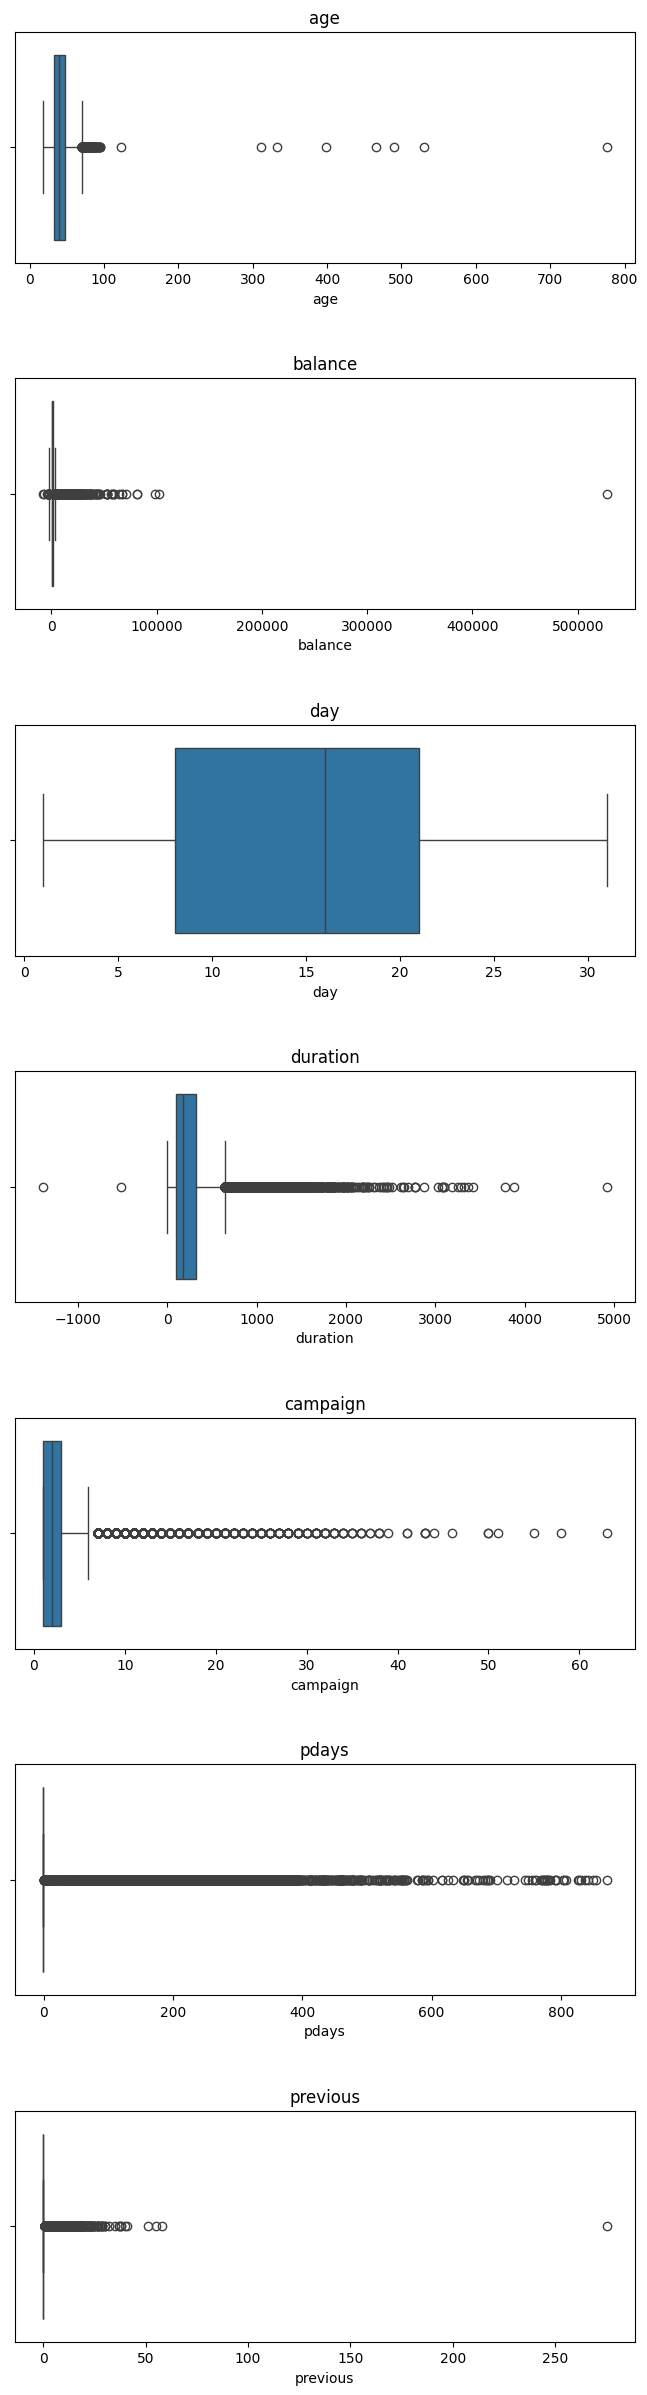

In [29]:
#Generar graficas individuales pues las variables numericas estan en rangos diferentes 

cols_num = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

fig, ax = plt.subplots(nrows=7, ncols=1, figsize=(8,30)) #Aqui se crea el espacio donde van a estar las graficas , es decir van haber 7 filas una por variable, 1 columna , y que tengan 8 de ancho y 30 de alto 
fig.subplots_adjust(hspace=0.5) #Ajuste del espacio vertical entre graficos para que no este uno encima del otro 

for i, col in enumerate(cols_num): #bucle paara que recorra una por una la columna 
    sns.boxplot(x=col ,  data=data , ax=ax[i]) #Creacion de grafica donde x es la columna que se esta graficando , data es el dataframe que estamos usando y ax en que espacio dibujar 
    ax[i].set_title(col) #Se coloca el titulo del nombre de la variable 

**Observaciones**:

- **age:** Hay personas con edades mucho mayores a 100 años.  
- **balance:** Hay posiblemente una cuenta con ingresos mayores a 500 mil dólares; este outlier es poco visible pero posible, así que no se le hará ningún tipo de limpieza.  
- **day:** El rango está correcto; no existen días mayores a 30 o 31.  
- **duration:** Hay duraciones negativas; esto es irrelevante ya que las llamadas duran entre 1 y 5 minutos.  
- **campaign:** Se evidencian las veces que han llamado a la persona durante la campaña.  
- **pdays:** Los días después de la última llamada están relativamente bien.  
- **previous:** Hay un valor extremadamente alto (cercano a 300 llamadas), lo cual es irrelevante.  

In [30]:
# Eiminar filas con age > 100
print(f'Tamaño del set antes de eliminar registros de edad: {data.shape}')
data = data[data['age']<=100]
print(f'Tamaño del set despues de eliminar registros de edad : {data.shape}')

Tamaño del set antes de eliminar registros de edad: (45203, 17)
Tamaño del set despues de eliminar registros de edad : (45195, 17)


In [31]:
# Eiminar filas con duracion < 0
print(f'Tamaño del set antes de eliminar registros de duracion: {data.shape}')
data = data[data['duration']>0]
print(f'Tamaño del set despues de elimianr registros de duracion{data.shape}')

Tamaño del set antes de eliminar registros de duracion: (45195, 17)
Tamaño del set despues de elimianr registros de duracion(45190, 17)


In [32]:
print(f'Tamaño del set antes de eliminar registros  de previous: {data.shape}')
data = data[data['previous']<=100]
print(f'Tamaño del set después de eliminar registros de previous: {data.shape}')


Tamaño del set antes de eliminar registros  de previous: (45190, 17)
Tamaño del set después de eliminar registros de previous: (45189, 17)


## Errores tipograficos en variables categoricas

En una variable categorica pueden aparecer sub-niveles  como "unknow" y "UNK" que para nosotros es equivalentes pero para nuestro programa no lo es , asi que se deben unificar estos sub-niveles asi.

C:\Users\erodriguezs\AppData\Local\Temp\ipykernel_18512\842733557.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30)
C:\Users\erodriguezs\AppData\Local\Temp\ipykernel_18512\842733557.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30)
C:\Users\erodriguezs\AppData\Local\Temp\ipykernel_18512\842733557.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30)
C:\Users\erodriguezs\AppData\Local\Temp\ipykernel_18512\842733557.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].se

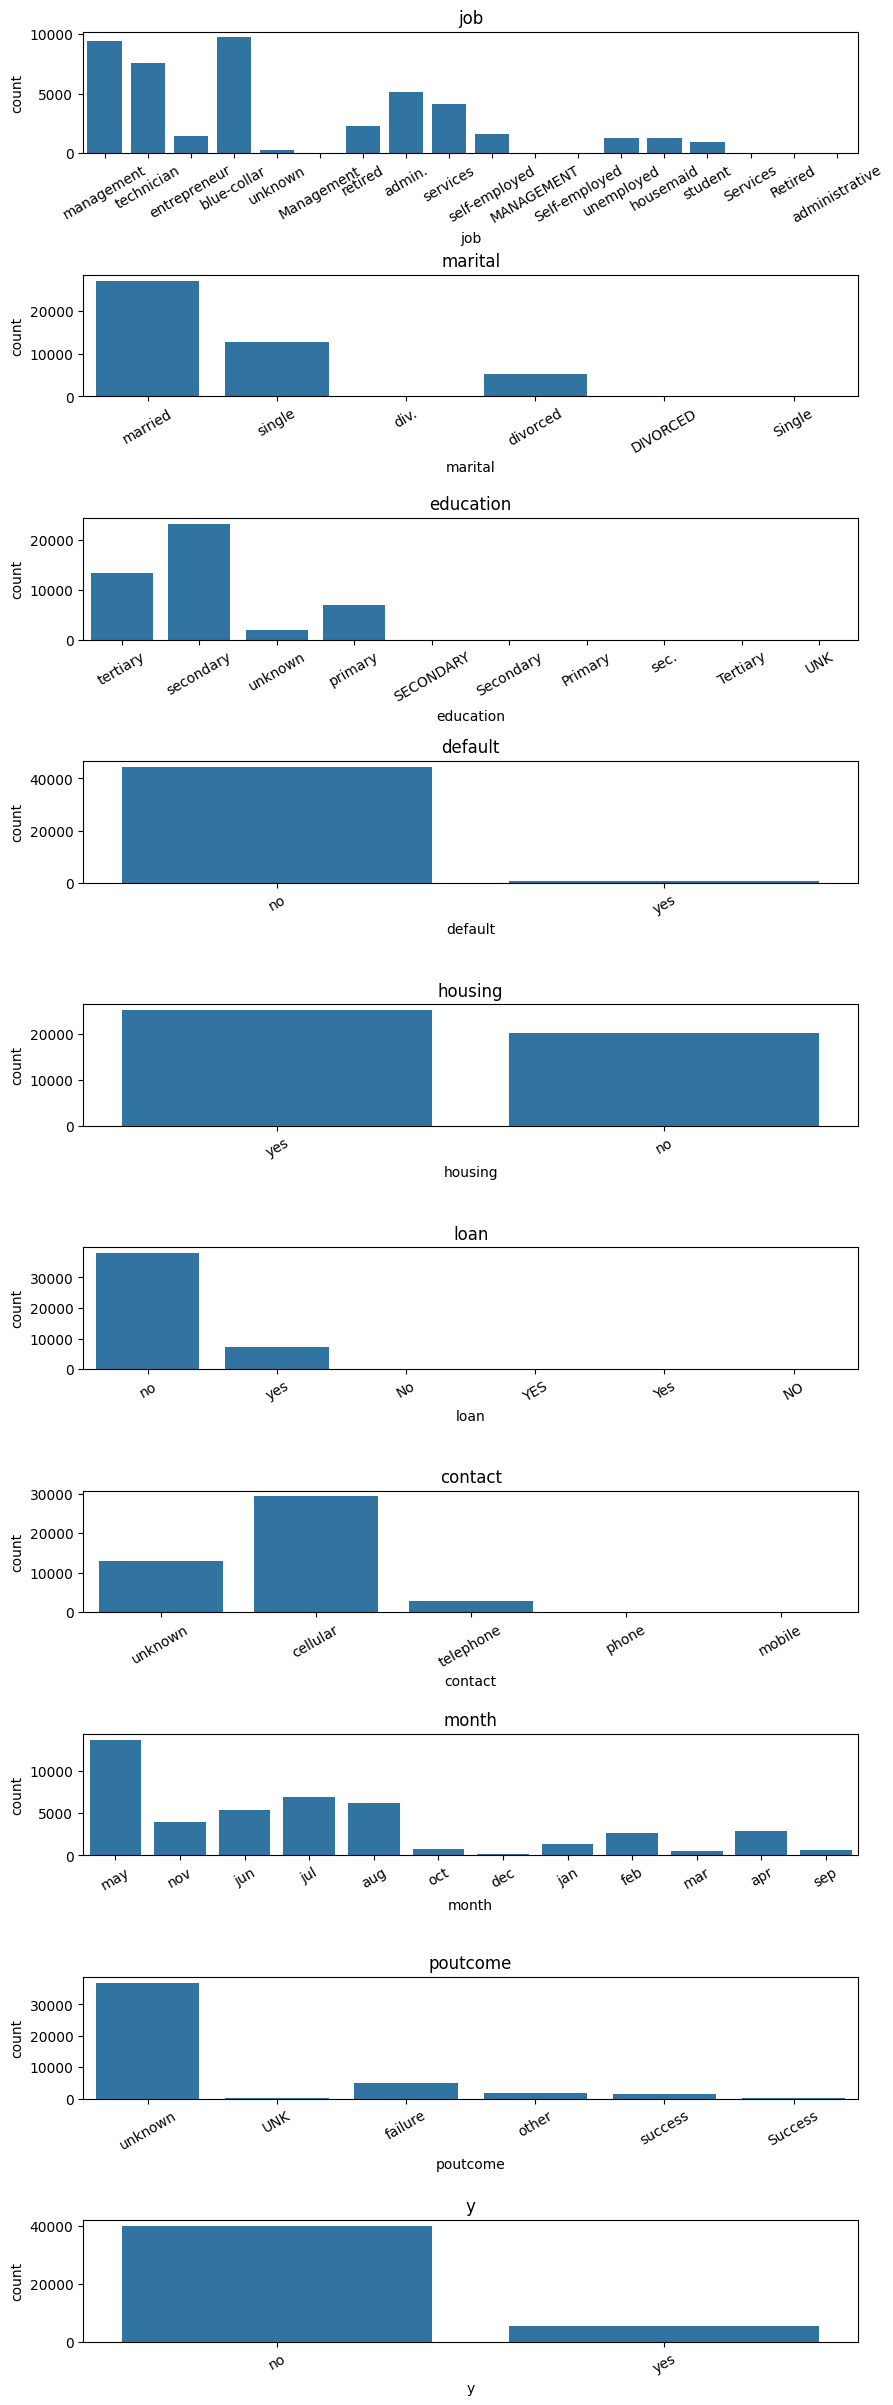

In [ ]:
# Lista con los nombres de las variables categóricas del DataFrame
cols_cat = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'contact',
            'month', 'poutcome', 'y']

# Crear una figura con:
# - 10 filas de gráficas
# - 1 columna
# figsize = tamaño total de la figura (ancho, alto)
fig, ax = plt.subplots(nrows=10, ncols=1, figsize=(10,30))

# Ajustar el espacio vertical entre gráficas
# hspace = espacio entre filas
fig.subplots_adjust(hspace=1)

# Recorrer cada variable categórica
# i = posición de la gráfica
# col = nombre de la columna
for i, col in enumerate(cols_cat):

    # Crear gráfico de conteo
    # x=col -> variable a graficar
    # data=data -> DataFrame donde están los datos
    # ax=ax[i] -> posición donde irá la gráfica
    sns.countplot(x=col, data=data, ax=ax[i])

    # Colocar título a cada gráfica
    ax[i].set_title(col)

    # Rotar etiquetas del eje X 30 grados
    # Esto evita que los textos se encimen
    ax[i].set_xticklabels(
        ax[i].get_xticklabels(),
        rotation=30
    )

Se puede evidenciar que hay subniveles escritos en mayuscula o que la primera letra inicia en mayuscula , pero equivalen al mismo sub nivel entonces vamos a proceder a unificar estos subniveles 

C:\Users\erodriguezs\AppData\Local\Temp\ipykernel_18512\41800746.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(
C:\Users\erodriguezs\AppData\Local\Temp\ipykernel_18512\41800746.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(
C:\Users\erodriguezs\AppData\Local\Temp\ipykernel_18512\41800746.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(
C:\Users\erodriguezs\AppData\Local\Temp\ipykernel_18512\41800746.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(
C:\Users\erodriguezs\AppData\Local\Temp\ipykernel_18512\41800746.py:25: UserWarning: set_ticklabels(

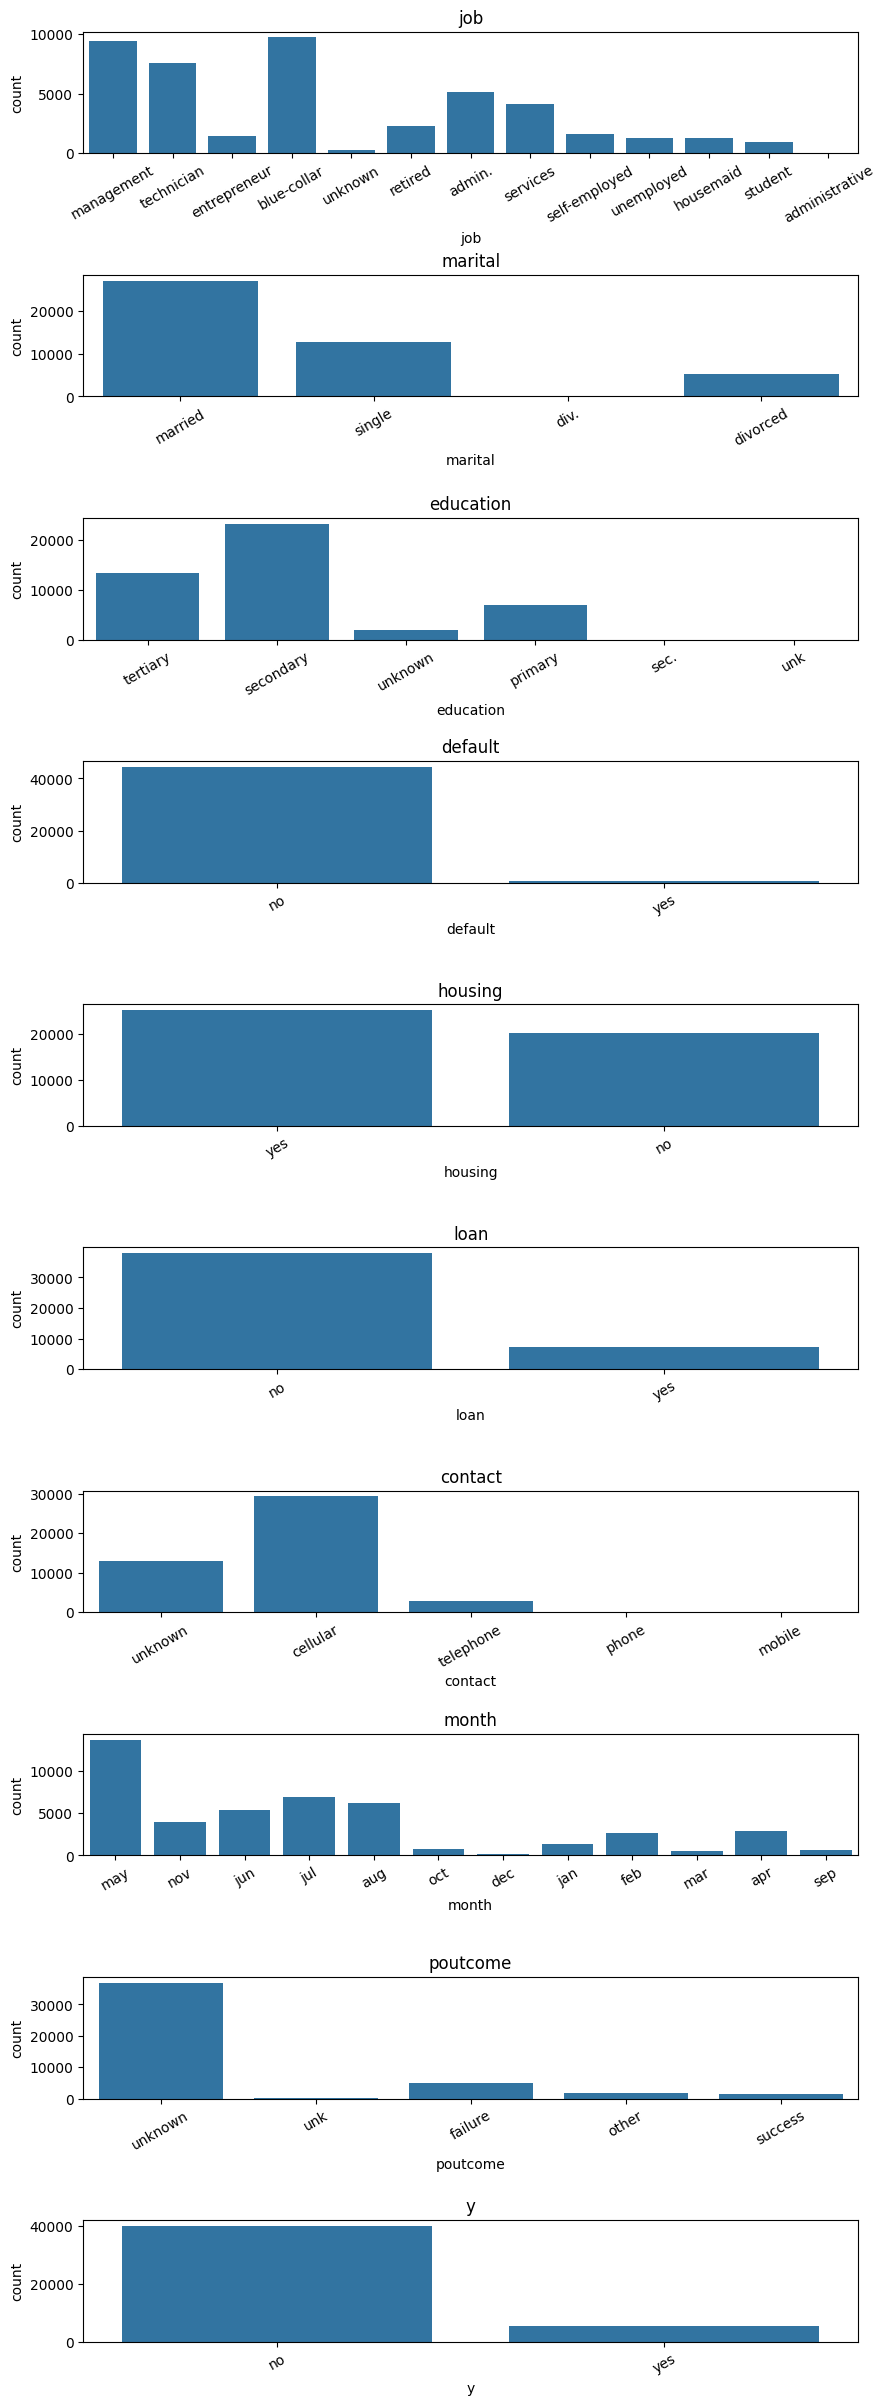

In [35]:
# Recorrer todas las columnas del DataFrame
for column in data.columns:

    # Verificar si la columna actual está dentro
    # de la lista de variables categóricas
    if column in cols_cat:

        # Convertir todos los textos de la columna a minúsculas
        # .str.lower() funciona sobre columnas tipo texto
        data[column] = data[column].str.lower()


fig, ax = plt.subplots(nrows=10, ncols=1, figsize=(10,30))
fig.subplots_adjust(hspace=1)

for i, col in enumerate(cols_cat):

    sns.countplot(
        x=col,       
        data=data,   
        ax=ax[i]     
    )

    ax[i].set_title(col)
    ax[i].set_xticklabels(
        ax[i].get_xticklabels(),
        rotation=30
    )